order 0 mean 4.048762858371335 stddev 1.8976921787998957
order 1 mean 4.360277742582957 stddev 1.7022199922614356
order 2 mean 4.217887314779636 stddev 1.105527187503965
order 3 mean 3.316499877450591 stddev 1.0574172433303866
order 4 mean 1.3876851613288337 stddev 0.2035472889075067
order 5 mean 1.4219162517148114 stddev 0.1999609865167598
order 6 mean 1.4784520664600993 stddev 0.6128925440094812
order 7 mean 1.1313501589120556 stddev 0.3967850376932698
order 8 mean 1.8330048215549333 stddev 1.6817090072324687
order 9 mean 2.1433110038289485 stddev 2.19596940373121
order 10 mean 2.278732764298315 stddev 2.2057523202315887
order 11 mean 9.169574687704191 stddev 14.836076820551545
order 12 mean 14.055908536144603 stddev 24.003232037547
order 13 mean 36.24993249362785 stddev 63.50846127452095
order 14 mean 28.132182540284543 stddev 49.64484657035661


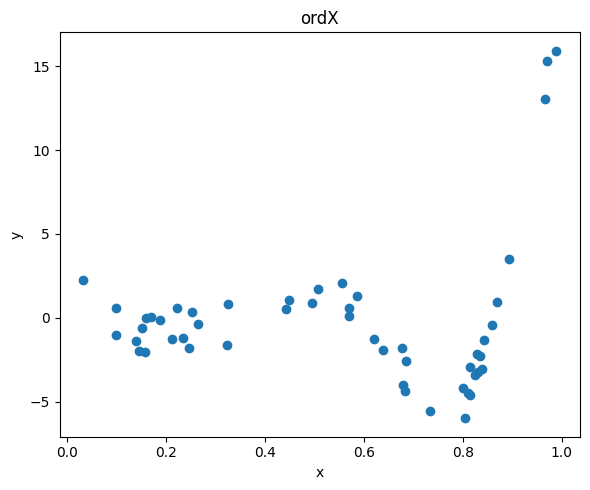

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [2]:
import sys
# todo Windows
sys.path.append("../cpcrr")

import cpcrr as cp


if __name__ == '__main__':

    f = cp.functions.onevar

    xmin = 0
    xmax = 1

    # npoints 20: mean dips slightly, skyrockets
    # npoints 50: mean falls, rises
    # npoints ≥100: mean falls, will not rise until order is high, likely higher than numerics allow

    x, y = cp.functions.function_noise_1d(f, xmin = xmin, xmax = xmax, npoints=50, stddev = 1.0)
    cp.functions.quickplot_scatter(x, y, f"Data set")

    PF = cp.methods.Polynomial1DFitter(xmin, xmax, x, y)

    plot = False
    min_order = 0
    max_order = 15
    for order in range(min_order, max_order):
        # fix the seed, or the fold sets will differ as order changes
        loss, mean, stddev = PF.fit_and_cross_validate(order=order, n_folds=5, plot = plot, seed = 14)
        print(f"order {order} mean {mean} stddev {stddev}")


